# Lab 03 - Simple and Multiple Linear Regression

## Water Temperature and Salinity Prediction



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [49]:
import os
from google.colab import files

file_name = 'Water_Temperature_pred.csv'

if not os.path.exists(file_name):
    uploaded = files.upload()
else:
    print("File already exists. Upload skipped.")

File already exists. Upload skipped.


In [50]:
df = pd.read_csv('Water_Temperature_pred.csv')

df.head()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# Check required columns
df[['Depthm', 'T_degC', 'STheta', 'Salnty']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420502 entries, 0 to 420501
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Depthm  420502 non-null  int64  
 1   T_degC  413794 non-null  float64
 2   STheta  379142 non-null  float64
 3   Salnty  382146 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 12.8 MB


In [52]:
# Check missing values
df[['Depthm', 'T_degC', 'STheta', 'Salnty']].isnull().sum()

,0
Depthm,0
T_degC,6708
STheta,41360
Salnty,38356


In [53]:
# Prepare data for Simple Linear Regression
simple_data = df[['T_degC', 'Salnty']].dropna()

print("Original dataset shape:", df.shape)
print("Simple regression dataset shape:", simple_data.shape)

simple_data.head()

Original dataset shape: (420502, 74)
Simple regression dataset shape: (379142, 2)


,T_degC,Salnty
0,10.50,33.440
1,10.46,33.440
2,10.46,33.437
3,10.45,33.420
4,10.45,33.421


In [54]:
# Define input and output variables
X = simple_data[['T_degC']]
y = simple_data['Salnty']

print("Input variable shape:", X.shape)
print("Output variable shape:", y.shape)

Input variable shape: (379142, 1)
Output variable shape: (379142,)


In [55]:
# Define input and output variables
X = simple_data[['T_degC']]
y = simple_data['Salnty']

print("Input variable shape:", X.shape)
print("Output variable shape:", y.shape)

Input variable shape: (379142, 1)
Output variable shape: (379142,)


In [56]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (303313, 1)
Testing data shape: (75829, 1)


In [57]:
# Create and train the Simple Linear Regression model
simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [58]:
# Make predictions on the test data
y_pred = simple_model.predict(X_test)

print("First 5 predicted values:")
print(y_pred[:5])

First 5 predicted values:
[34.05591332 33.94644763 34.01019776 33.72248336 33.91834725]


In [59]:
# Evaluate the Simple Linear Regression model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.18107132740417684
R2 Score: 0.1637510722608434


In [60]:
# Prepare data for Multiple Linear Regression

multiple_data = df[['T_degC', 'Depthm', 'STheta', 'Salnty']].dropna()

print("Multiple regression dataset shape:", multiple_data.shape)

multiple_data.head()

Multiple regression dataset shape: (379142, 4)


,T_degC,Depthm,STheta,Salnty
0,10.50,0,25.649,33.440
1,10.46,8,25.656,33.440
2,10.46,10,25.654,33.437
3,10.45,19,25.643,33.420
4,10.45,20,25.643,33.421


In [61]:
# Define input and output variables for Multiple Linear Regression

X_multiple = multiple_data[['T_degC', 'Depthm', 'STheta']]
y_multiple = multiple_data['Salnty']

print("Input variables shape:", X_multiple.shape)
print("Output variable shape:", y_multiple.shape)

Input variables shape: (379142, 3)
Output variable shape: (379142,)


In [62]:
# Split the data into training and testing sets for Multiple Linear Regression

X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

print("Training input shape:", X_train_multiple.shape)
print("Testing input shape:", X_test_multiple.shape)
print("Training output shape:", y_train_multiple.shape)
print("Testing output shape:", y_test_multiple.shape)

Training input shape: (303313, 3)
Testing input shape: (75829, 3)
Training output shape: (303313,)
Testing output shape: (75829,)


In [63]:
# Create and train the Multiple Linear Regression model

multiple_model = LinearRegression()

multiple_model.fit(X_train_multiple, y_train_multiple)

print("Multiple Linear Regression model trained successfully")

Multiple Linear Regression model trained successfully


In [64]:
# Make predictions using the Multiple Linear Regression model

y_pred_multiple = multiple_model.predict(X_test_multiple)

print("First 5 predicted values:")
print(y_pred_multiple[:5])

First 5 predicted values:
[34.00993561 33.81063972 33.86829673 33.30345928 33.51495705]


In [65]:
# Evaluate the Multiple Linear Regression model

mse_multiple = mean_squared_error(y_test_multiple, y_pred_multiple)
r2_multiple = r2_score(y_test_multiple, y_pred_multiple)

print("Mean Squared Error:", mse_multiple)
print("R2 Score:", r2_multiple)

Mean Squared Error: 0.012951006371410542
R2 Score: 0.9401878511275263


In [66]:
# Compare Simple and Multiple Linear Regression models

print("MODEL COMPARISON")
print("----------------------------")
print("Simple Linear Regression")
print("MSE:", mse)
print("R2 Score:", r2)

print("\nMultiple Linear Regression")
print("MSE:", mse_multiple)
print("R2 Score:", r2_multiple)

MODEL COMPARISON
----------------------------
Simple Linear Regression
MSE: 0.18107132740417684
R2 Score: 0.1637510722608434

Multiple Linear Regression
MSE: 0.012951006371410542
R2 Score: 0.9401878511275263


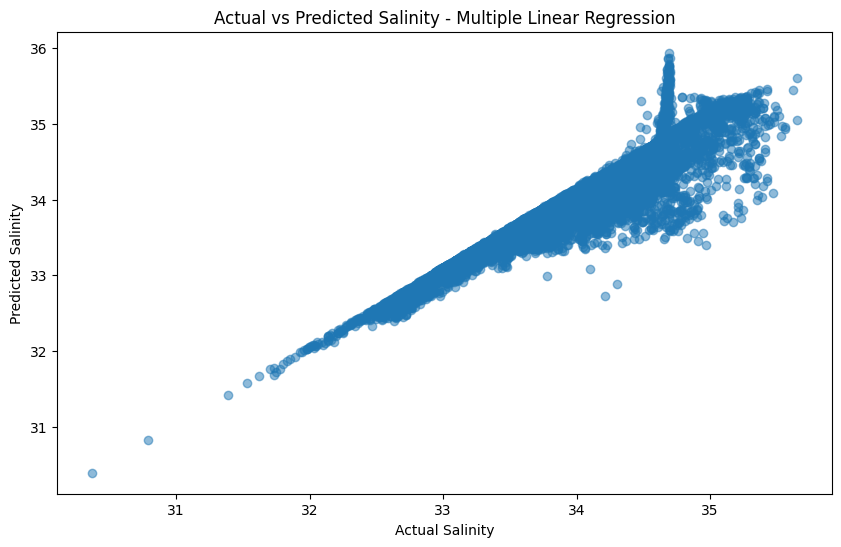

In [67]:
# Visualize Actual vs Predicted values

plt.figure(figsize=(10, 6))

plt.scatter(y_test_multiple, y_pred_multiple, alpha=0.5)

plt.xlabel("Actual Salinity")
plt.ylabel("Predicted Salinity")
plt.title("Actual vs Predicted Salinity - Multiple Linear Regression")

plt.show()

In [68]:
# Display Multiple Linear Regression model coefficients

print("Multiple Linear Regression Model Details")
print("----------------------------------------")

print("Intercept:", multiple_model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X_multiple.columns, multiple_model.coef_):
    print(feature, ":", coefficient)

Multiple Linear Regression Model Details
----------------------------------------
Intercept: -2.8501640697985238

Coefficients:
T_degC : 0.2690773355641361
Depthm : 0.0004447469428952985
STheta : 1.3044932704563739


In [69]:
# Predict Salinity for new water conditions

new_data = pd.DataFrame({
    'T_degC': [10.50],
    'Depthm': [20],
    'STheta': [25.643]
})

predicted_salinity = multiple_model.predict(new_data)

print("New Input Data:")
print(new_data)

print("\nPredicted Salinity:", predicted_salinity[0])

New Input Data:
   T_degC  Depthm  STheta
0    10.5      20  25.643

Predicted Salinity: 33.43516382679561


In [70]:
# Final Summary

print("FINAL RESULTS")
print("-" * 40)

print("\nSimple Linear Regression")
print("MSE:", mse)
print("R2 Score:", r2)

print("\nMultiple Linear Regression")
print("MSE:", mse_multiple)
print("R2 Score:", r2_multiple)

print("\nConclusion:")
print("Multiple Linear Regression performed better than Simple Linear Regression.")
print("It achieved a higher R2 Score and lower Mean Squared Error.")
print("Therefore, using Temperature, Depth, and STheta together gives better Salinity predictions.")

FINAL RESULTS
----------------------------------------

Simple Linear Regression
MSE: 0.18107132740417684
R2 Score: 0.1637510722608434

Multiple Linear Regression
MSE: 0.012951006371410542
R2 Score: 0.9401878511275263

Conclusion:
Multiple Linear Regression performed better than Simple Linear Regression.
It achieved a higher R2 Score and lower Mean Squared Error.
Therefore, using Temperature, Depth, and STheta together gives better Salinity predictions.
